# HW 7

### Minh Truong
### 141225

Perform the following activities in Python:    

- Get the dataset - pick any one of the datasets from the Dataset folder.
- Load the .csv file into a data frame in Python.
- Describe the data, provide information on the dataset.
- Preprocess data if needed.
- Conduct SVM Classification.
- Experiment with different kernel functions in SVC to see which one performs best for your data.  
- Generate classification report.  
- Provide metrics for precision, recall, and ROC.

# SVM Classification
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)
**Source:** UCI Machine Learning Repository
**Target:** Diagnosis (B = Benign, M = Malignant)

In [36]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc

## Get the Dataset - pick any one of the datasets from the Dataset folder.
I chose the Wisconsin Diagnostic Breast Cancer (WDBC) dataset.
It has 569 instances, 30 features, no missing values.

## Load the .csv file into a data frame in Python.

In [37]:
#Define column names because wdbc.data has no header. The names were sourced from wdbc.names documentation
columns = ['id', 'diagnosis',
           'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
           'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean',
           'symmetry_mean', 'fractal_dimension_mean',
           'radius_se', 'texture_se', 'perimeter_se', 'area_se',
           'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se',
           'symmetry_se', 'fractal_dimension_se',
           'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
           'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst',
           'symmetry_worst', 'fractal_dimension_worst']

# Load dataset into dataframe df
df = pd.read_csv('/Users/mtruong/python-projects/BZAN 6355/wdbc.data', header=None, names=columns)

# Provides first 5 rows of dataset
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Describe the data, provide information on the dataset.

In [38]:
# Provides the summary statistics: count, mean, std, min, max for all features
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [51]:
# Check that there no missing values
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [52]:
# Class distribution: 357 Benign, 212 Malignant
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

## Preprocess the data if needed.

In [41]:
# Drop ID, encode target, scale features

# Drop the ID column as it is not a predictive feature
df.drop(columns=['id'], inplace=True)

# Encode the target variable: B = 0 (Benign), M = 1 (Malignant)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

# Define the feature matrix and target vector
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Split the dataset into 80% train, 20% test, and stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Standardize features to fit on train only to prevent data leakage into test set
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Experiment with different kernel functions in SVC to see which one performs best for your data. 

In [49]:
# Test four kernels: linear, rbf, poly, and sigmoid kernels to find the best performing model
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
for kernel in kernels:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    print(f"Kernel: {kernel:<10} Accuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

Kernel: linear     Accuracy: 0.9649
Kernel: rbf        Accuracy: 0.9737
Kernel: poly       Accuracy: 0.8860
Kernel: sigmoid    Accuracy: 0.9474


In [43]:
# Train the final model using the best kernel from the comparison above
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

## Generate classification report. 

In [50]:
# Provide the full breakdown of precision, recall, and F1-score per class
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## Provide metrics for precision, recall, and ROC.

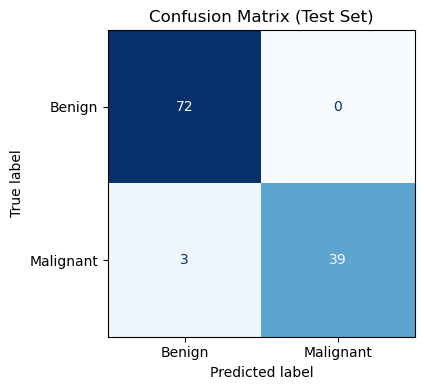

In [46]:
# Provide the confusion matrix on the test set to compare predicted vs actual diagnoses
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['Benign', 'Malignant']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

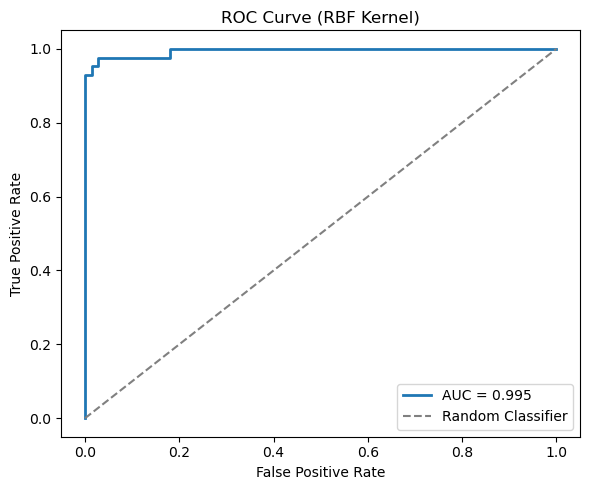

In [47]:
y_proba = svm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Classifier')
plt.title('ROC Curve (RBF Kernel)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

**Conclusion:**
The RBF kernel outperformed all other kernels on this breast cancer dataset. It achieved the highest accuracy and an AUC-ROC score of 0.995. This confirms the effectiveness of SVMs for high-dimensional medical classification tasks.